In [110]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import matplotlib as mpl


In [111]:
# filename = "graphs_images/gpu_cost_normal_proposed.jpg"
experiments = [
    {"id": "exp_20250625_014444", "name": "OpenWhisk"},
        {"id": "exp_20250625_071954", "name": "NMIG"},
        {"id": "exp_20250624_210136", "name": "Histogram"},
        {"id": "exp_20250624_165438", "name": "Pagurus"},
]


In [136]:
docker_log_path = f"../results/{experiments[3]['id']}/docker_log.csv"
gpu_usage_path = f"../results/{experiments[1]['id']}/gpu_usage.csv"

In [137]:
df = pd.read_csv(docker_log_path)

In [138]:
df

,1750751715000,goofy_almeida2,pandeymanish93/ml-inference:efficientnet-v1.0,running
0,1750751715000,sleepy_poitras,pandeymanish93/ml-inference:efficientnet-v1.0,running
1,1750751715000,eager_lederberg,pandeymanish93/ml-inference:efficientnet-v1.0,running
2,1750751716000,goofy_almeida2,pandeymanish93/ml-inference:efficientnet-v1.0,running
3,1750751716000,optimistic_elgamal,pandeymanish93/ml-inference:efficientnet-v1.0,running
4,1750751716000,angry_borg,pandeymanish93/ml-inference:efficientnet-v1.0,running
...,...,...,...,...
140493,1750765935000,xenodochial_nash,pandeymanish93/ml-inference:distilgpt2-v1.0,paused
140494,1750765936000,xenodochial_nash,pandeymanish93/ml-inference:distilgpt2-v1.0,paused
140495,1750765937000,xenodochial_nash,pandeymanish93/ml-inference:distilgpt2-v1.0,paused
140496,1750765938000,xenodochial_nash,pandeymanish93/ml-inference:distilgpt2-v1.0,paused


In [139]:
"""
Categorization (reuse) + idle/active GPU-memory evaluation.

Matches the actual recorded files:

  docker_log.csv : NO HEADER. columns are
                   timestamp, container_name, image_name, status
                   status in {running, paused, ...}
  gpu_usage.csv  : HAS HEADER:
                   Timestamp, ContainerID, ImageName, GPU_Memory_MB

IMPORTANT about the join:
  docker_log identifies containers by NAME (e.g. infallible_hawking)
  gpu_usage  identifies containers by short ID (e.g. 3c5b16a43de1)
  These do not match, so the idle/active split is joined on
  (timestamp, image) -- coarser, aggregate per image, not per container.

Produces:
  [1] containers-per-image (reuse / scale-out per category)         -> bar
  [2] running vs paused containers over time                        -> line
  [3] idle (paused) vs active (running) GPU memory over time         -> stacked
  [4] cumulative unique containers created over time                 -> line
Numbers dumped to container_results.json.

Run:
  python analyze_containers.py --docker docker_log.csv --gpu gpu_usage.csv
"""

from __future__ import annotations
import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


RUNNING_STATES = {"running"}
PAUSED_STATES = {"paused"}


def _short_image(name):
    s = str(name)
    if ":" in s:
        s = s.split(":")[-1]
    return s


def load_docker_log(path):
    # NO header in this file -- first data row was being eaten as header.
    df = pd.read_csv(path, header=None,
                     names=["timestamp", "container", "image", "status"])
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["t"] = (df["timestamp"] - df["timestamp"].min()) / 1000.0
    df["image_s"] = df["image"].map(_short_image)
    df["status"] = df["status"].astype(str).str.strip().str.lower()
    return df


def load_gpu(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    lower = {c.lower(): c for c in df.columns}
    ts = lower.get("timestamp")
    img = lower.get("imagename") or lower.get("image_name") or lower.get("image")
    mb = lower.get("gpu_memory_mb") or lower.get("gpu_mem_mb") or lower.get("gpu_memory")
    cid = lower.get("containerid") or lower.get("container_id") or lower.get("container")
    df = df.rename(columns={ts: "timestamp", img: "image", mb: "gpu_mb", cid: "cid"})
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["t"] = (df["timestamp"] - df["timestamp"].min()) / 1000.0
    df["gpu_mb"] = pd.to_numeric(df["gpu_mb"], errors="coerce").fillna(0.0)
    df["image_s"] = df["image"].map(_short_image)
    return df


def inspect(dock, gpu):
    print("=" * 70)
    print("INSPECTION")
    print("=" * 70)
    print(f"docker_log: {len(dock)} rows")
    print(f"  status values: {sorted(dock['status'].unique())}")
    print(f"  images: {sorted(dock['image_s'].unique())}")
    print(f"  unique container names: {dock['container'].nunique()}")
    print(f"gpu_usage : {len(gpu)} rows")
    print(f"  images: {sorted(gpu['image_s'].unique())}")
    print(f"  GPU_Memory_MB range: {gpu['gpu_mb'].min()}..{gpu['gpu_mb'].max()}")
    have = set(dock["status"].unique())
    if not (RUNNING_STATES & have):
        print(f"  [WARN] none of RUNNING_STATES {RUNNING_STATES} present in {have}")
    if not (PAUSED_STATES & have):
        print(f"  [WARN] none of PAUSED_STATES {PAUSED_STATES} present in {have}")
    print("=" * 70)


def analyse(dock, gpu, outdir):
    outdir.mkdir(parents=True, exist_ok=True)
    results = {}

    # [1] containers per image
    per_img = dock.groupby("image_s")["container"].nunique().sort_values(ascending=False)
    results["containers_per_image"] = {k: int(v) for k, v in per_img.items()}
    results["unique_containers_total"] = int(dock["container"].nunique())
    results["unique_images_total"] = int(dock["image_s"].nunique())
    print("\n[1] distinct containers per image:")
    for k, v in per_img.items():
        print(f"      {k:24s} {v}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(len(per_img)), per_img.to_numpy(), color="#1f77b4")
    ax.set_xticks(range(len(per_img)))
    ax.set_xticklabels(per_img.index, rotation=30, ha="right")
    ax.set_ylabel("Distinct containers")
    ax.set_title("Containers instantiated per image (scale-out per category)")
    ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(outdir / "containers_per_image.png", dpi=150)
    fig.savefig(outdir / "containers_per_image.pdf")
    plt.close(fig)

    # [2] running vs paused over time
    dock = dock.copy()
    dock["tbin"] = dock["t"].round(0)
    running = (dock[dock["status"].isin(RUNNING_STATES)]
               .groupby("tbin")["container"].nunique())
    paused = (dock[dock["status"].isin(PAUSED_STATES)]
              .groupby("tbin")["container"].nunique())
    allbins = sorted(set(running.index) | set(paused.index))
    run_y = running.reindex(allbins, fill_value=0).to_numpy()
    pau_y = paused.reindex(allbins, fill_value=0).to_numpy()
    results["peak_running_containers"] = int(run_y.max()) if len(run_y) else 0
    results["peak_paused_containers"] = int(pau_y.max()) if len(pau_y) else 0
    print(f"[2] peak running={results['peak_running_containers']}, "
          f"peak paused={results['peak_paused_containers']}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(allbins, run_y, label="running (active)", color="#2ca02c")
    ax.plot(allbins, pau_y, label="paused (idle, retained)", color="#d62728")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Containers")
    ax.set_title("Running vs paused containers over time")
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(outdir / "running_vs_paused.png", dpi=150)
    fig.savefig(outdir / "running_vs_paused.pdf")
    plt.close(fig)

    # [3] idle vs active GPU memory over time (join on tbin+image)
    gpu = gpu.copy()
    gpu["tbin"] = gpu["t"].round(0)

    dock_status = (dock.groupby(["tbin", "image_s"])["status"]
                   .agg(lambda s: "running" if (set(s) & RUNNING_STATES) else
                        ("paused" if (set(s) & PAUSED_STATES) else "other"))
                   .reset_index()
                   .rename(columns={"status": "img_status"}))

    gpu_bin = gpu.groupby(["tbin", "image_s"])["gpu_mb"].mean().reset_index()
    merged = gpu_bin.merge(dock_status, on=["tbin", "image_s"], how="left")
    merged["img_status"] = merged["img_status"].fillna("unknown")

    active = (merged[merged["img_status"] == "running"]
              .groupby("tbin")["gpu_mb"].sum())
    idle = (merged[merged["img_status"] == "paused"]
            .groupby("tbin")["gpu_mb"].sum())
    bins2 = sorted(set(active.index) | set(idle.index))
    a_y = active.reindex(bins2, fill_value=0).to_numpy()
    i_y = idle.reindex(bins2, fill_value=0).to_numpy()

    total_mb_s = float((a_y + i_y).sum())
    idle_mb_s = float(i_y.sum())
    results["idle_gpu_mb_fraction"] = round(idle_mb_s / total_mb_s, 4) if total_mb_s else 0.0
    results["peak_idle_gpu_mb"] = round(float(i_y.max()), 1) if len(i_y) else 0.0
    results["peak_active_gpu_mb"] = round(float(a_y.max()), 1) if len(a_y) else 0.0
    print(f"[3] idle GPU memory fraction (paused / total) = "
          f"{results['idle_gpu_mb_fraction']:.1%}")
    print(f"    peak idle={results['peak_idle_gpu_mb']} MB, "
          f"peak active={results['peak_active_gpu_mb']} MB")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.stackplot(bins2, a_y, i_y,
                 labels=["active (running)", "idle (paused)"],
                 colors=["#2ca02c", "#d62728"], alpha=0.8)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("GPU memory held (MB)")
    ax.set_title("Active vs idle GPU memory over time")
    ax.legend(loc="upper right"); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(outdir / "idle_vs_active_gpu.png", dpi=150)
    fig.savefig(outdir / "idle_vs_active_gpu.pdf")
    plt.close(fig)

    # [4] cumulative unique containers over time
    first_seen = dock.sort_values("t").drop_duplicates("container")
    ct = np.sort(first_seen["t"].to_numpy())
    cum = np.arange(1, len(ct) + 1)
    results["total_unique_containers"] = int(len(ct))
    fig, ax = plt.subplots(figsize=(8, 4))
    if len(ct):
        ax.step(ct, cum, where="post", color="#1f77b4")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Cumulative unique containers")
    ax.set_title("Unique containers created over time")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(outdir / "containers_over_time.png", dpi=150)
    fig.savefig(outdir / "containers_over_time.pdf")
    plt.close(fig)

    (outdir / "container_results.json").write_text(json.dumps(results, indent=2))
    print(f"\nSaved figures + container_results.json to {outdir}/")
    return results


# def main():
#     ap = argparse.ArgumentParser()
#     ap.add_argument("--docker", default="docker_log.csv")
#     ap.add_argument("--gpu", default="gpu_usage.csv")
#     ap.add_argument("--out", default="container_eval")
#     ap.add_argument("--inspect-only", action="store_true")
#     args = ap.parse_args()

#     dock = load_docker_log(args.docker)
#     gpu = load_gpu(args.gpu)
#     inspect(dock, gpu)
#     if args.inspect_only:
#         print("\n(inspect-only: stopping)")
#         return
#     analyse(dock, gpu, Path(args.out))



In [140]:
from pathlib import Path
import pandas as pd

def main(
    docker_csv="docker_log.csv",
    gpu_csv="gpu_usage.csv",
    outdir="container_outputs",
    show_figures=True
):
    """
    Notebook-friendly main function.

    Parameters
    ----------
    docker_csv : str
        Path to docker_log.csv.
        This file has NO header.

    gpu_csv : str
        Path to gpu_usage.csv.
        This file HAS a header.

    outdir : str
        Folder where figures and container_results.json will be saved.

    show_figures : bool
        If True, display generated figures inside the notebook.
    """

    docker_csv = Path(docker_csv)
    gpu_csv = Path(gpu_csv)
    outdir = Path(outdir)

    if not docker_csv.exists():
        raise FileNotFoundError(f"Docker log not found: {docker_csv}")

    if not gpu_csv.exists():
        raise FileNotFoundError(f"GPU usage file not found: {gpu_csv}")

    # Load data
    dock = load_docker_log(docker_csv)
    gpu = load_gpu(gpu_csv)

    # Inspect loaded files
    inspect(dock, gpu)

    # Run analysis
    results = analyse(dock, gpu, outdir)

    # Display results in notebook
    print("\nRESULT SUMMARY")
    print("=" * 70)
    for key, value in results.items():
        print(f"{key}: {value}")

    if show_figures:
        from IPython.display import display, Image, Markdown

        figure_files = [
            "containers_per_image.png",
            "running_vs_paused.png",
            "idle_vs_active_gpu.png",
            "containers_over_time.png",
        ]

        for fig_name in figure_files:
            fig_path = outdir / fig_name
            if fig_path.exists():
                title = fig_name.replace("_", " ").replace(".png", "").title()
                display(Markdown(f"### {title}"))
                display(Image(filename=str(fig_path)))

    return results

INSPECTION
docker_log: 140499 rows
  status values: ['paused', 'removing', 'running']
  images: ['alexnet-v1.0', 'bert-v1.0', 'distilgpt2-v1.0', 'efficientnet-v1.0', 'googlenet-v1.0', 'inception-v1.0', 'resnet50-v1.0']
  unique container names: 173
gpu_usage : 1267 rows
  images: ['alexnet-v1.2', 'bert-v1.2', 'distilgpt2-v1.2', 'efficientnet-v1.2', 'inception-v1.2', 'resnet50-v1.2']
  GPU_Memory_MB range: 10.0..1270.0

[1] distinct containers per image:
      bert-v1.0                65
      efficientnet-v1.0        65
      distilgpt2-v1.0          17
      alexnet-v1.0             9
      googlenet-v1.0           8
      inception-v1.0           6
      resnet50-v1.0            4
[2] peak running=32, peak paused=42
[3] idle GPU memory fraction (paused / total) = 0.0%
    peak idle=0.0 MB, peak active=0.0 MB

Saved figures + container_results.json to container_outputs/

RESULT SUMMARY
containers_per_image: {'bert-v1.0': 65, 'efficientnet-v1.0': 65, 'distilgpt2-v1.0': 17, 'alexnet-v1.

### Containers Per Image

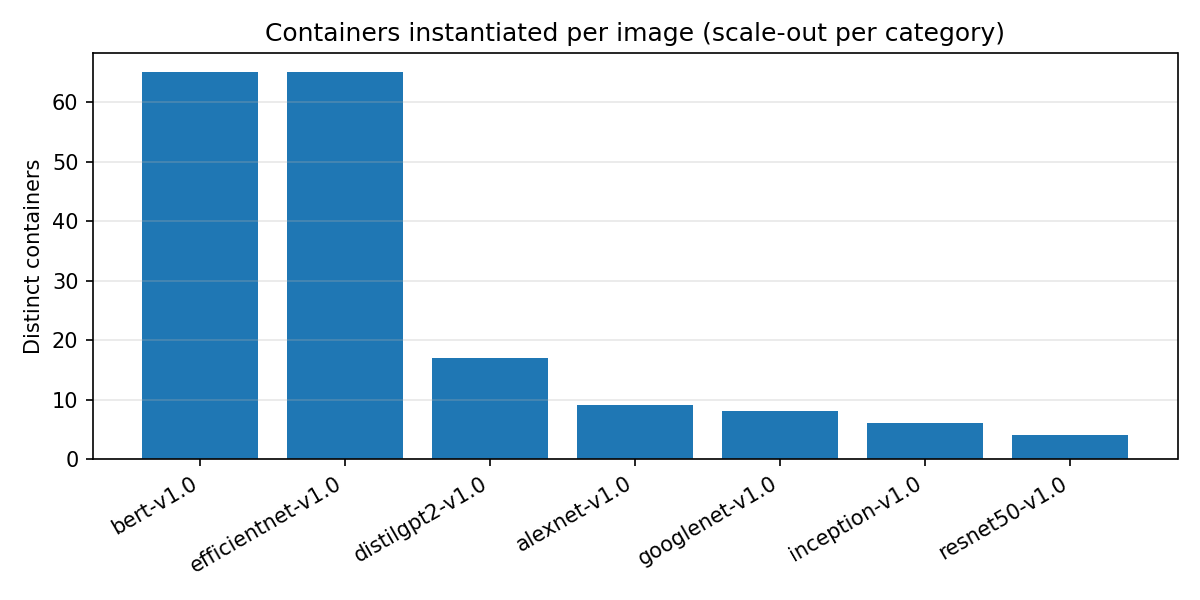

### Running Vs Paused

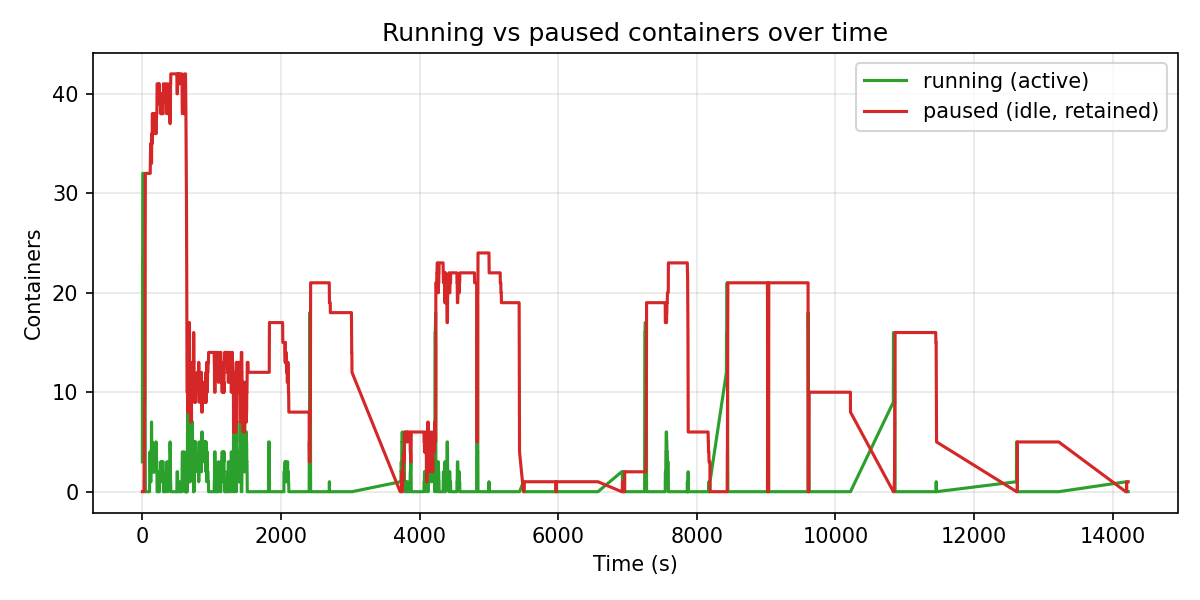

### Idle Vs Active Gpu

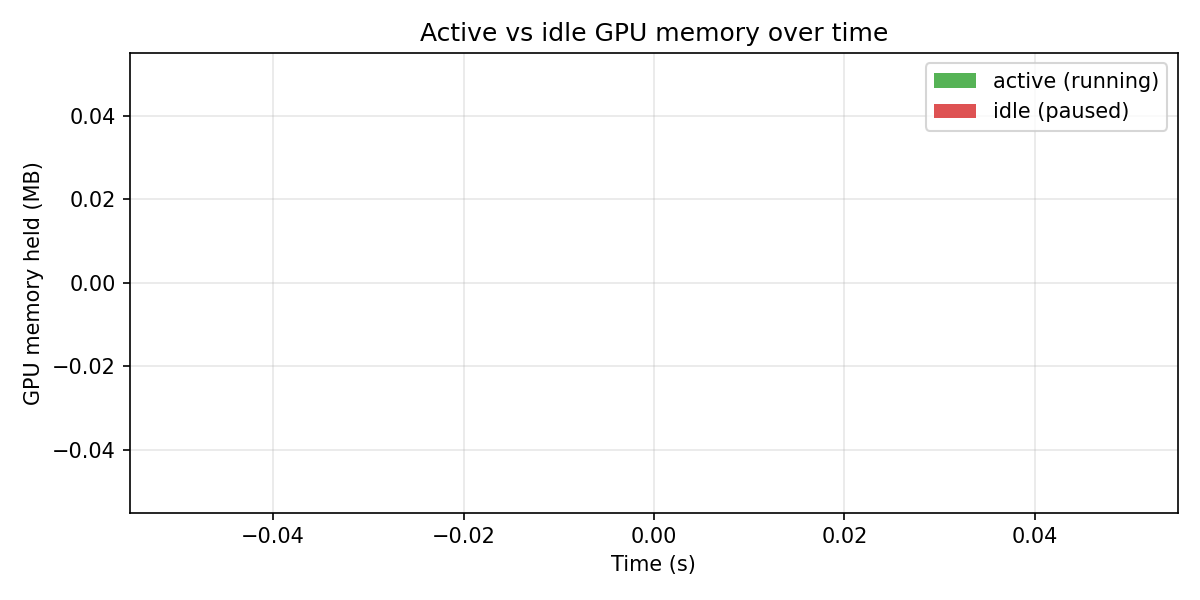

### Containers Over Time

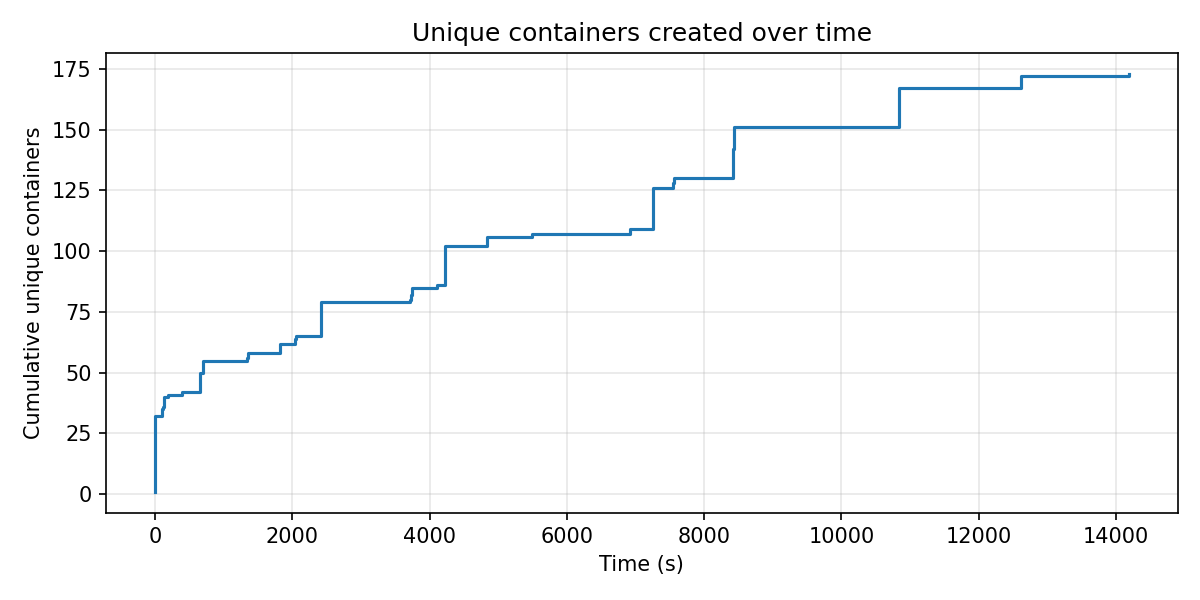

In [141]:
results = main(
    docker_csv=docker_log_path,
    gpu_csv=gpu_usage_path,
    outdir="container_outputs",
    show_figures=True
)